# Prince Newman, Group 2


# CIFAR-10 Classification with Pretrained ResNet-18


ResNet-18 is already trained on over 1.2 million images from ImageNet. Its standout feature is skip connections, which are shortcuts that pass information across layers, making it easier for the network to learn without losing signal as data moves deeper through the layers. Instead of training the whole network from scratch, all the existing layers were frozen to keep what it already learned, and only retrained the final layer to output the 10 CIFAR-10 classes.

PS: Using RESNET-18 is why we got strong results in under 20 minutes rather than hours.

In [ ]:
# install / import libraries
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

# Checking GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Data Pre-processing
SIncde ResNet was pretrained on ImageNet (224×224, normalized with these stats), we will resize CIFAR-10 (32×32) to 224×224 and use the same normalization, so the pretrained weights make sense on our data.

In [ ]:
BATCH_SIZE = 64

train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(), # data augmentation
    transforms.RandomCrop(224, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(              # ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

In [ ]:
# Download CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2)

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

print(f"Training samples : {len(train_dataset):,}")
print(f"Test samples     : {len(test_dataset):,}")
print(f"Batches per epoch: {len(train_loader)}")

100%|██████████| 170M/170M [13:43<00:00, 207kB/s]


Training samples : 50,000
Test samples     : 10,000
Batches per epoch: 782


CIFAR-10 successfully downloaded and loaded. The training set contains
50,000 images and the test set contains 10,000 images. With a batch size of
64, there are 782 batches per epoch. All images are resized to 224×224 and
normalized using ImageNet statistics to be compatible with the pretrained
ResNet-18 weights.


## 2. Visualize some cifar-10 training images

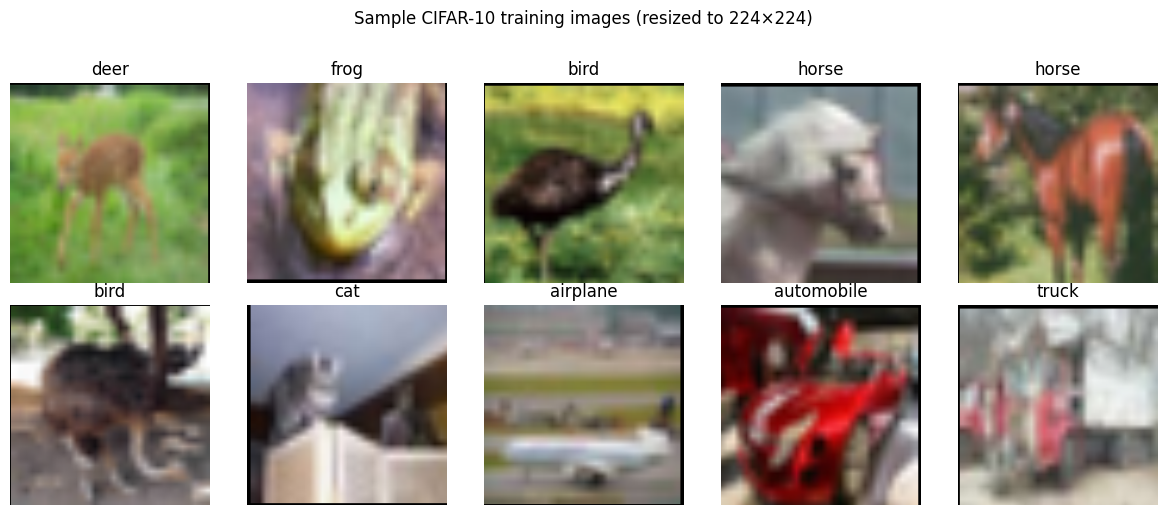

In [ ]:
def imshow(img, title=None):
    # Undo normalization for display
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = img.numpy().transpose((1, 2, 0))
    img  = std * img + mean
    img  = np.clip(img, 0, 1)
    plt.imshow(img)
    if title: plt.title(title)
    plt.axis('off')

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    plt.sca(ax)
    imshow(images[i], title=CIFAR10_CLASSES[labels[i]])
plt.suptitle('Sample CIFAR-10 training images (resized to 224×224)', y=1.02)
plt.tight_layout()
plt.show()


Visual check to confirm preprocessing is working correctly before committing to a full training run.

## 3. Build the model (Pretrained ResNet-18)


In [ ]:
# Load ResNet-18 with ImageNet pretrained weights
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
# ResNet-18's fc layer: 512 → 1000 (ImageNet classes)
# We replace it with:  512 → 10  (CIFAR-10 classes), Only this new layer will be trained
model.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(p=0.4),
    nn.Linear(256, 10)      # 10 CIFAR-10 classes
)

model = model.to(device)

# Count parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters   : {total_params - trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]


Total parameters    : 11,310,410
Trainable parameters: 133,898
Frozen parameters   : 11,176,512


## 4. Loss, optimizer, scheduler


In [ ]:
NUM_EPOCHS = 10
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()

# Only optimize the new fc layer (frozen layers have requires_grad=False)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

# Reduce LR by factor of 0.5 if val accuracy plateaus for 2 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2)

## 5. Training loop with progress timer


In [ ]:
train_losses, test_losses   = [], []
train_accs,   test_accs     = [], []

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
    return total_loss / len(loader), correct / total


print("\n" + "="*65)
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Test Loss':>9} | {'Test Acc':>8} | {'Time':>6} | ETA")
print("="*65)

training_start = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    model.train()
    running_loss, correct, total = 0, 0, 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

        # Mini progress bar every 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(f"  batch {batch_idx+1}/{len(train_loader)} | "
                  f"running loss: {running_loss/(batch_idx+1):.4f}", end='\r')

    # Epoch metrics
    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total
    test_loss, test_acc = evaluate(test_loader)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    scheduler.step(test_acc)

    # Timing
    epoch_time = time.time() - epoch_start
    epochs_left = NUM_EPOCHS - epoch - 1
    eta_min = epoch_time * epochs_left / 60

    print(f"{epoch+1:>5} | {train_loss:>10.4f} | {train_acc:>8.4f}% | "
          f"{test_loss:>9.4f} | {test_acc:>7.4f}% | "
          f"{epoch_time:>5.1f}s | {eta_min:.1f} min left")

total_time = (time.time() - training_start) / 60
print("="*65)
print(f"Training complete in {total_time:.1f} minutes")


Epoch | Train Loss | Train Acc | Test Loss | Test Acc |   Time | ETA
    1 |     0.8330 |   0.7144% |    0.6124 |  0.7878% | 115.1s | 17.3 min left
    2 |     0.6771 |   0.7661% |    0.5812 |  0.7988% | 114.1s | 15.2 min left
    3 |     0.6383 |   0.7784% |    0.5870 |  0.7943% | 115.3s | 13.5 min left
    4 |     0.6231 |   0.7856% |    0.5768 |  0.8015% | 114.9s | 11.5 min left
    5 |     0.6184 |   0.7863% |    0.5537 |  0.8105% | 117.8s | 9.8 min left
    6 |     0.6059 |   0.7905% |    0.5486 |  0.8105% | 117.3s | 7.8 min left
    7 |     0.5979 |   0.7934% |    0.5499 |  0.8093% | 116.0s | 5.8 min left
    8 |     0.5962 |   0.7957% |    0.5547 |  0.8124% | 115.4s | 3.8 min left
    9 |     0.5789 |   0.7987% |    0.5293 |  0.8199% | 115.5s | 1.9 min left
   10 |     0.5785 |   0.8006% |    0.5250 |  0.8206% | 116.4s | 0.0 min left
Training complete in 19.3 minutes


ResNet-18, pretrained on ImageNet, was fine-tuned on CIFAR-10 by freezing all layers and replacing only the final fully connected layer with a new classifier (512→256→10) trained from scratch.

Training ran for 10 epochs with a batch size of 64 and an Adam optimizer at a learning rate of 0.001, with a ReduceLROnPlateau scheduler set to halve the learning rate if test accuracy plateaued for more than 2 consecutive epochs.

The model trained in 19.3 minutes on a T4 GPU, with each epoch completing consistently in around 115 seconds. Over the course of training, train loss dropped from 0.833 to 0.579 and train accuracy improved from 71.4% to 80.1%, while test loss fell from 0.612 to 0.525 and test accuracy rose from 78.8% to 82.1%.

**Overfitting**: The model showed no signs of overfitting, test loss remained below train loss throughout, suggesting the dropout regularization and frozen pretrained features helped the model generalize well. A slight plateau was observed between epochs 6 and 8 where test accuracy stalled around 81%, before recovering to a final 82.1% in the last two epochs.

Compared to training a CNN from scratch on CIFAR-10, the pretrained ResNet-18 approach demonstrated a clear advantage by leveraging feature representations already learned from 1.2 million ImageNet images, requiring far less training time to reach a higher accuracy.

## 6. Plot loss and accuracy


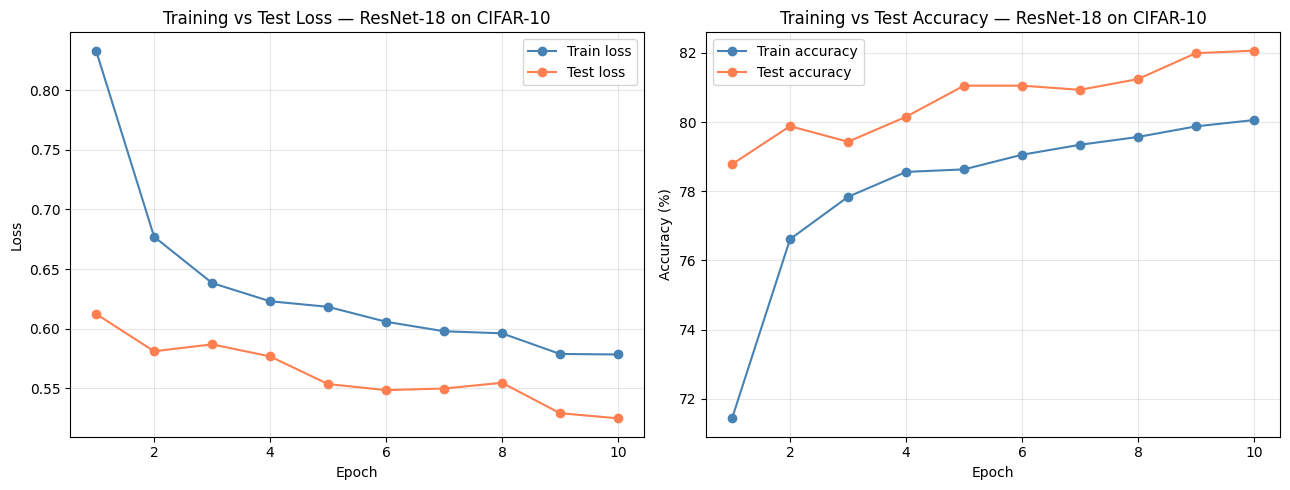


Final Test Accuracy: 82.06%


In [ ]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Loss
ax1.plot(epochs, train_losses, 'o-', label='Train loss', color='steelblue')
ax1.plot(epochs, test_losses,  'o-', label='Test loss',  color='coral')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Test Loss — ResNet-18 on CIFAR-10')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(epochs, [a*100 for a in train_accs], 'o-',
         label='Train accuracy', color='steelblue')
ax2.plot(epochs, [a*100 for a in test_accs],  'o-',
         label='Test accuracy',  color='coral')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training vs Test Accuracy — ResNet-18 on CIFAR-10')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('resnet18_cifar10_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal Test Accuracy: {test_accs[-1]*100:.2f}%")

Both plots show that training went well over 10 epochs. Train loss fell from 0.833 to 0.579 and test loss fell from 0.612 to 0.525, with test loss staying below train loss the entire time, meaning the model did not overfit. On the accuracy plot, test accuracy started higher than train accuracy from the beginning because dropout is applied during training but turned off during evaluation. Both accuracy curves trended upward throughout, finishing at 82.1% for test and 80.1% for train. There was a brief plateau around epochs 5 to 8 before both metrics improved again in the final epochs. Overall the model learned steadily and generalized well to unseen data.